# Exploratory Data Analysis (EDA)

## Business Objective

ElderGuard Analytics aims to develop a non-invasive monitoring system capable of identifying elderly residents' activity levels using environmental sensor and indoor air quality data.

This analysis investigates the relationships between environmental conditions, gas sensor measurements, HVAC operations, lighting conditions, and resident activity behavior. The primary objective is to understand the dataset structure, identify potential data quality issues, discover meaningful patterns, and support the development of robust machine learning models for activity level prediction.

The findings from this EDA will guide preprocessing strategies, feature engineering decisions, model selection, and evaluation methodologies for the subsequent machine learning pipeline.

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Dataset Loading

The dataset is stored in an SQLite database and contains environmental sensor readings collected from elderly residents’ homes. The data is loaded into a Pandas DataFrame for analysis.

In [3]:
conn = sqlite3.connect("../data/raw/gas_monitoring.db")

df = pd.read_sql_query(
    "SELECT * FROM gas_monitoring",
    conn
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## Initial Dataset Inspection

This section provides a high-level overview of the dataset structure, including the number of records, feature types, and sample observations.

In [4]:
df.head()

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


In [5]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (10000, 14)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        8946 non-null   object 
 13  Activity Level             10000 non-null  obje

### Initial Dataset Observations

The dataset contains 10,000 records and 14 features representing environmental conditions, indoor air quality measurements, HVAC operations, lighting conditions, and resident activity levels.

The dataset includes a mixture of:
- Numerical sensor measurements (e.g., temperature, humidity, CO2 sensors, gas sensors)
- Contextual categorical features (e.g., Time of Day, HVAC Operation Mode, Ambient Light Level)
- A categorical target variable (`Activity Level`) for classification modeling.

Several features contain missing values:
- `Humidity`
- `MetalOxideSensor_Unit2`
- `CO_GasSensor`
- `Ambient Light Level`

This indicates that data quality assessment and missing value handling will be important preprocessing steps before model training.

The dataset structure appears suitable for supervised machine learning classification tasks, particularly for predicting resident activity levels based on environmental and air quality conditions.

## Data Quality Assessment

Data quality assessment is an important step in the machine learning pipeline as missing values, inconsistent records, and contaminated data may negatively impact model performance and reliability.

This section evaluates the completeness of the dataset by identifying missing values across all features.

In [7]:
df.isnull().sum()

Time of Day                     0
Temperature                     0
Humidity                     1928
CO2_InfraredSensor              0
CO2_ElectroChemicalSensor       0
MetalOxideSensor_Unit1          0
MetalOxideSensor_Unit2       1410
MetalOxideSensor_Unit3          0
MetalOxideSensor_Unit4          0
CO_GasSensor                  834
Session ID                      0
HVAC Operation Mode             0
Ambient Light Level          1054
Activity Level                  0
dtype: int64

### Missing Value Analysis

Several sensor and contextual features contain missing values. Understanding the proportion of missing data is important for determining appropriate preprocessing and imputation strategies.

High missingness may indicate:
- sensor malfunction
- transmission issues
- incomplete environmental recordings
- synthetic contamination within the dataset

The missing value percentages are calculated below for further assessment.

In [8]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage.sort_values(ascending=False)

Humidity                     19.28
MetalOxideSensor_Unit2       14.10
Ambient Light Level          10.54
CO_GasSensor                  8.34
Time of Day                   0.00
Temperature                   0.00
CO2_InfraredSensor            0.00
CO2_ElectroChemicalSensor     0.00
MetalOxideSensor_Unit1        0.00
MetalOxideSensor_Unit3        0.00
MetalOxideSensor_Unit4        0.00
Session ID                    0.00
HVAC Operation Mode           0.00
Activity Level                0.00
dtype: float64

### Missing Value Observations

Several features contain missing values, particularly:
- Humidity (19.28%)
- MetalOxideSensor_Unit2 (14.10%)
- Ambient Light Level (10.54%)
- CO_GasSensor (8.34%)

No feature exceeds 20% missingness, so feature removal is not necessary at this stage.

These missing values may indicate:
- intermittent sensor failures
- incomplete environmental recordings
- data contamination during collection

Appropriate imputation strategies will be required during preprocessing before model training.

## Missing Value Visualization

Visualizing missing data patterns helps identify the severity and distribution of incomplete records across the dataset.

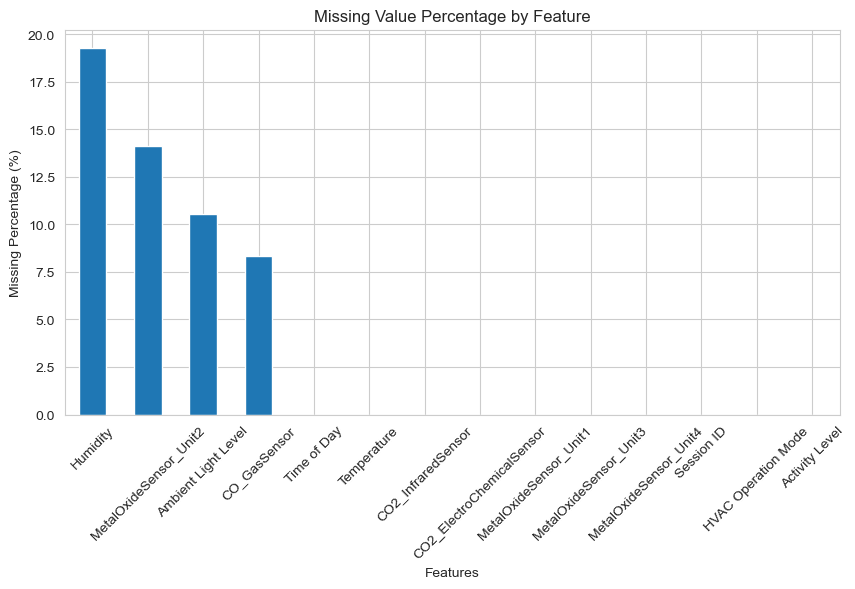

In [9]:
plt.figure(figsize=(10, 5))

missing_percentage.sort_values(ascending=False).plot(
    kind="bar"
)

plt.title("Missing Value Percentage by Feature")
plt.xlabel("Features")
plt.ylabel("Missing Percentage (%)")

plt.xticks(rotation=45)

plt.show()

## Duplicate Record Detection

Duplicate records can introduce bias into machine learning models and affect evaluation reliability.

This step checks whether duplicate observations exist within the dataset.

In [10]:
df.duplicated().sum()

171

### Duplicate Record Observations

The dataset contains 171 duplicate records.

Duplicate observations may:
- introduce bias into machine learning models
- artificially inflate model performance
- reduce dataset reliability

Since duplicate rows do not provide additional information, they will likely be removed during preprocessing to improve data quality and model generalization.

## Creating Processed Dataset

To preserve the integrity of the original dataset, a separate processed dataset is created for cleaning and preprocessing operations.

This allows comparison between raw and cleaned data throughout the analysis workflow.

In [11]:
df_processed = df.copy()

print("Processed dataset created successfully.")

Processed dataset created successfully.


## Duplicate Removal

Duplicate records are removed to ensure

In [12]:
df_processed = df_processed.drop_duplicates()

print("Updated Processed Dataset Shape:", df_processed.shape)
print("Duplicates remaining:", df_processed.duplicated().sum())

Updated Processed Dataset Shape: (9829, 14)
Duplicates remaining: 0


## Missing Value Handling

Missing values are handled using imputation techniques to preserve important sensor information while improving dataset completeness.

For numerical sensor measurements, median imputation is preferred because it is more robust to outliers compared to mean imputation.

For categorical features, mode imputation is used to replace missing values with the most frequent category.

In [13]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9829 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                9829 non-null   object 
 1   Temperature                9829 non-null   float64
 2   Humidity                   7912 non-null   float64
 3   CO2_InfraredSensor         9829 non-null   float64
 4   CO2_ElectroChemicalSensor  9829 non-null   float64
 5   MetalOxideSensor_Unit1     9829 non-null   float64
 6   MetalOxideSensor_Unit2     8423 non-null   float64
 7   MetalOxideSensor_Unit3     9829 non-null   float64
 8   MetalOxideSensor_Unit4     9829 non-null   float64
 9   CO_GasSensor               8999 non-null   float64
 10  Session ID                 9829 non-null   int64  
 11  HVAC Operation Mode        9829 non-null   object 
 12  Ambient Light Level        8777 non-null   object 
 13  Activity Level             9829 non-null   object 
dt

### Imputation Strategy

The dataset contains both numerical and categorical missing values.

Imputation strategies:
- Numerical sensor features → median imputation
- Categorical features → mode imputation

Median imputation is preferred for sensor readings because environmental measurements may contain outliers or skewed distributions.

In [14]:
numerical_columns = [
    "Humidity",
    "MetalOxideSensor_Unit2",
    "CO_GasSensor"
]

for column in numerical_columns:
    median_value = df_processed[column].median()
    df_processed[column] = df_processed[column].fillna(median_value)

print("Numerical missing values handled successfully.")

Numerical missing values handled successfully.


In [15]:
categorical_columns = [
    "Ambient Light Level"
]

for column in categorical_columns:
    mode_value = df_processed[column].mode()[0]
    df_processed[column] = df_processed[column].fillna(mode_value)

print("Categorical missing values handled successfully.")

Categorical missing values handled successfully.


In [16]:
df_processed.isnull().sum()

Time of Day                  0
Temperature                  0
Humidity                     0
CO2_InfraredSensor           0
CO2_ElectroChemicalSensor    0
MetalOxideSensor_Unit1       0
MetalOxideSensor_Unit2       0
MetalOxideSensor_Unit3       0
MetalOxideSensor_Unit4       0
CO_GasSensor                 0
Session ID                   0
HVAC Operation Mode          0
Ambient Light Level          0
Activity Level               0
dtype: int64

### Missing Value Handling Summary

All missing values in the processed dataset have been successfully handled using:
- median imputation for numerical sensor features
- mode imputation for categorical features

The processed dataset is now complete and ready for deeper exploratory analysis and feature relationship investigation.

# Univariate Analysis

Univariate analysis examines the distribution and characteristics of individual variables independently.

This helps identify:
- data distribution patterns
- skewness
- unusual values
- class imbalance
- potential outliers

## Numerical Feature Analysis

This section examines the distributions of numerical sensor features to identify:
- distribution patterns
- skewness
- unusual sensor readings
- potential outliers

Understanding these characteristics is important before feature engineering and model training.

In [17]:
numerical_features = [
    "Temperature",
    "Humidity",
    "CO2_InfraredSensor",
    "CO2_ElectroChemicalSensor",
    "MetalOxideSensor_Unit1",
    "MetalOxideSensor_Unit2",
    "MetalOxideSensor_Unit3",
    "MetalOxideSensor_Unit4",
    "CO_GasSensor"
]

df_processed[numerical_features].describe()

,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor
count,9829.000000,9829.000000,9829.000000,9829.000000,9829.000000,9829.000000,9829.000000,9829.000000,9829.000000
mean,42.618136,51.600275,109.848163,578.636295,470.984757,728.150590,680.493270,612.271345,1.264116
std,74.559993,19.326470,33.981285,22.576476,51.487102,26.987124,56.205247,43.174539,0.750143
min,6.903485,-49.870000,-17.472184,408.599386,286.825662,611.168916,456.673900,412.791904,0.000000
25%,18.930000,48.770000,96.535194,559.357007,440.102481,712.881032,658.480170,585.441906,1.000000
50%,20.510000,51.380000,112.803655,579.361082,469.147229,726.780828,679.857406,609.492784,1.000000
75%,23.180000,53.180000,124.563798,595.569759,494.783365,741.251350,703.593749,636.177403,2.000000
max,307.070000,198.900000,237.873938,637.895790,632.891693,807.732943,906.213097,736.112361,4.000000


### Numerical Feature Observations

Several suspicious sensor readings were identified during statistical analysis:

- Temperature contains an extremely high maximum value (307.07)
- Humidity contains negative values
- CO2 infrared sensor readings include negative measurements

These values are likely caused by:
- sensor malfunction
- calibration errors
- noisy environmental readings
- data contamination

Further outlier and invalid value analysis is required before modeling.

## Distribution Visualization

Histograms are used to examine the distribution of numerical sensor features and identify:
- skewed distributions
- unusual sensor behavior
- potential outliers
- abnormal measurement ranges

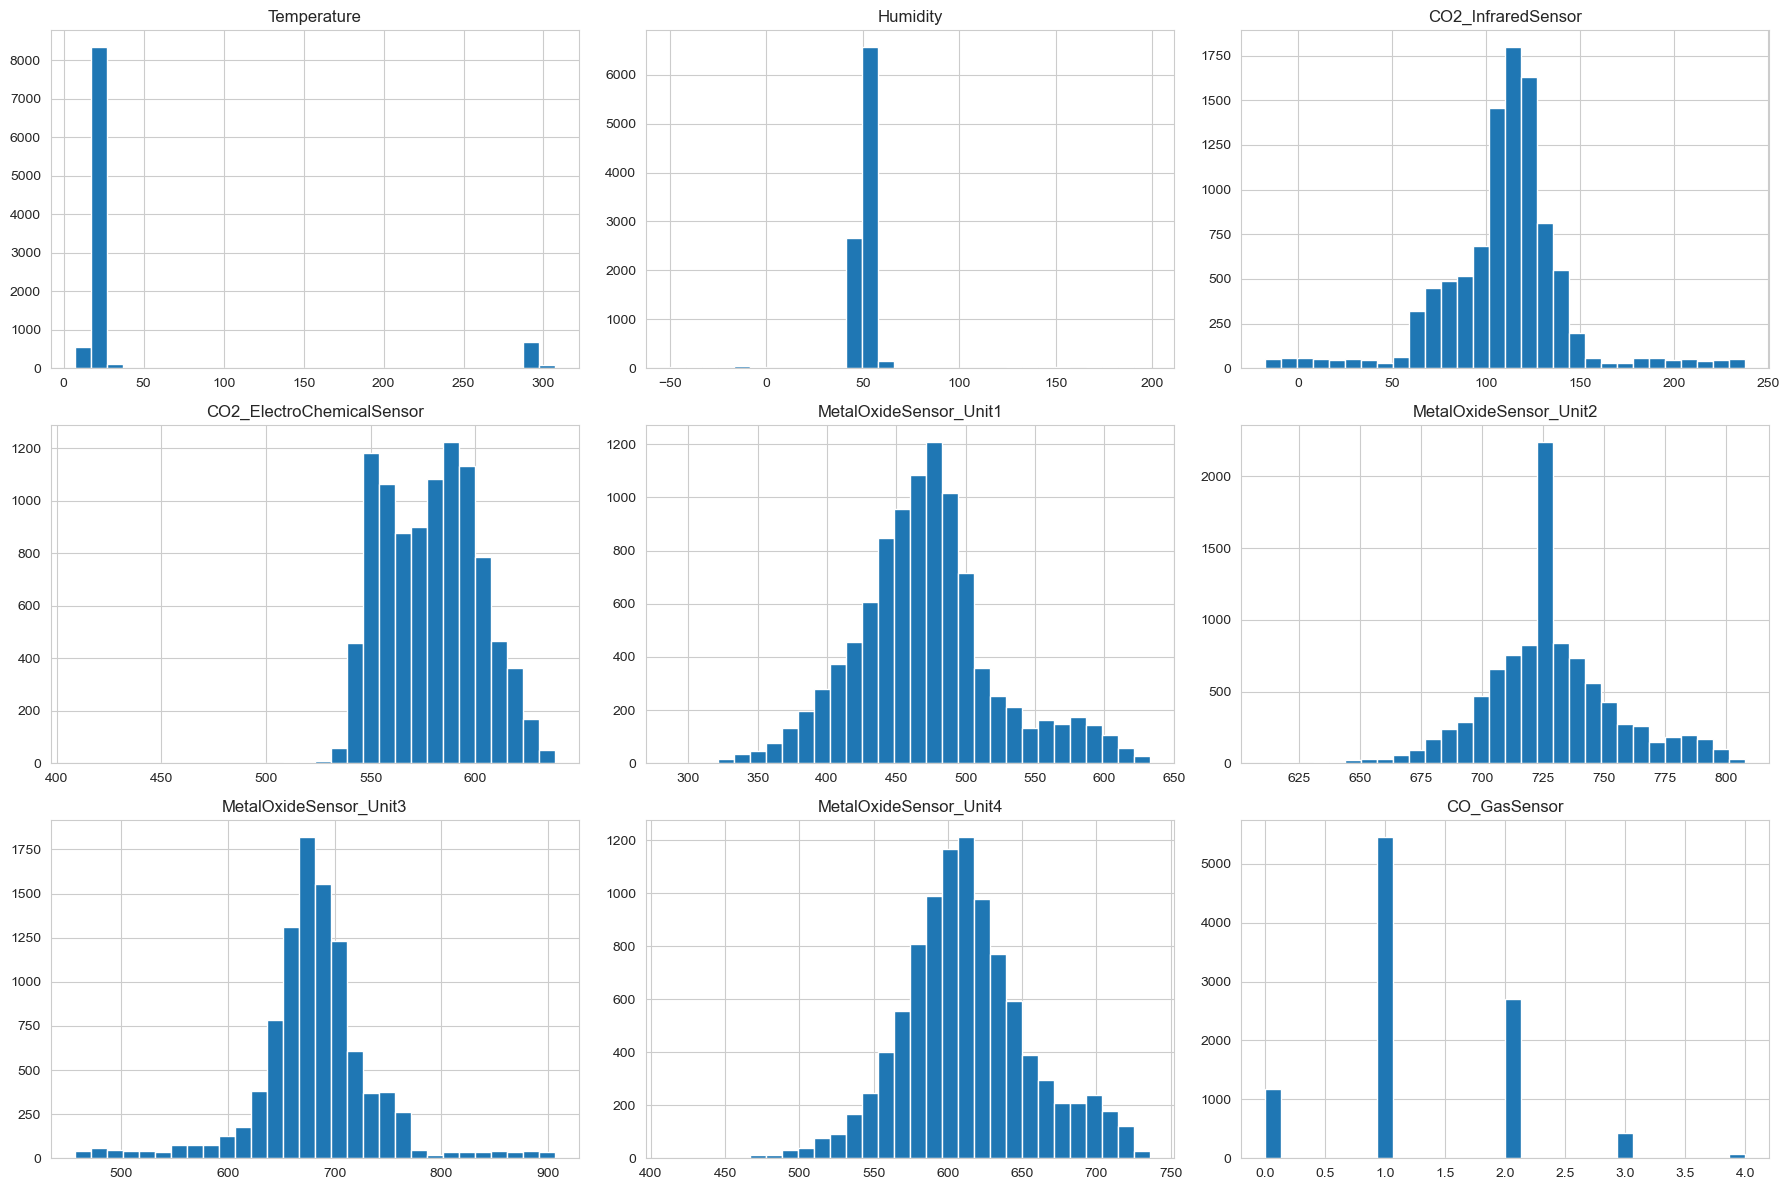

In [18]:
df_processed[numerical_features].hist(
    figsize=(18, 12),
    bins=30
)

plt.tight_layout()
plt.show()

### Distribution Observations

Several numerical features show non-normal distributions and abnormal sensor behavior.

Key findings:
- Temperature contains extreme outliers above 300
- Humidity includes physically impossible negative values
- CO2 infrared sensor readings contain negative measurements and long-tailed distributions
- Metal oxide sensor features appear approximately normally distributed with moderate skewness
- CO gas sensor values appear highly discrete, suggesting categorical or encoded sensor levels

These findings indicate that additional outlier and invalid value handling may be necessary before model training.

## Outlier Visualization

Boxplots are used to identify extreme values and abnormal sensor readings across numerical features.

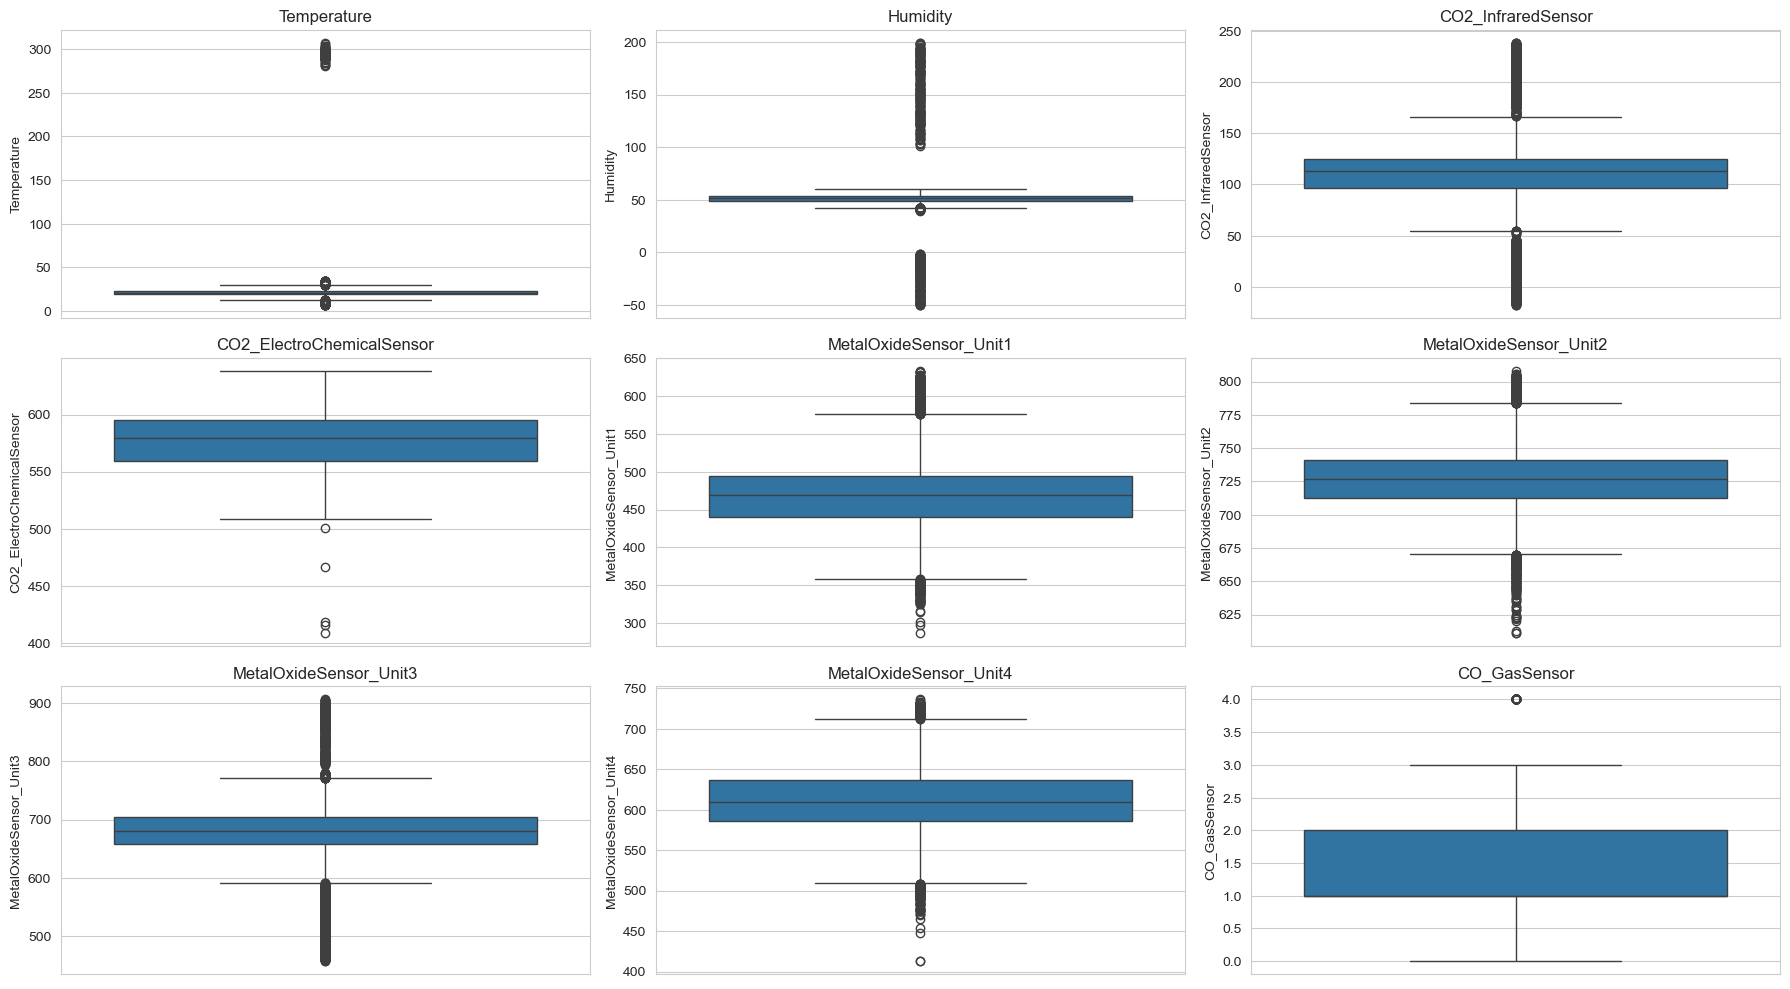

In [19]:
plt.figure(figsize=(18, 10))

for i, column in enumerate(numerical_features, 1):
    
    plt.subplot(3, 3, i)
    
    sns.boxplot(
        y=df_processed[column]
    )
    
    plt.title(column)

plt.tight_layout()
plt.show()

### Boxplot Observations

The boxplots reveal several extreme sensor readings and abnormal measurement patterns.

Key observations:
- Temperature contains severe upper outliers above 280
- Humidity contains invalid negative values and unusually high readings
- CO2 infrared sensor shows wide variability with both lower and upper outliers
- Metal oxide sensor features contain moderate outliers but maintain relatively stable distributions
- CO gas sensor appears more stable with limited extreme values

These findings suggest that selective outlier handling and invalid value treatment may improve model reliability.

## Numerical Data Validation

This section validates numerical sensor readings using domain knowledge and physical constraints to identify unrealistic or invalid measurements before model training.

Unlike generic statistical cleaning, validation decisions are based on:
- environmental monitoring principles
- sensor behavior
- physical measurement constraints
- dataset context provided in the attribute descriptions

### CO2 Sensor Validation

Carbon dioxide concentration cannot physically be negative. However, small negative values may occur in infrared sensor systems due to:
- calibration drift
- baseline noise
- temporary sensor offsets

Since only a small proportion of negative values were detected, these readings are treated as sensor noise and clipped to zero instead of removing entire rows.

In [20]:
print("Negative CO2 InfraredSensor values:")
print((df_processed["CO2_InfraredSensor"] < 0).sum())

print("\nNegative CO2 ElectroChemicalSensor values:")
print((df_processed["CO2_ElectroChemicalSensor"] < 0).sum())

Negative CO2 InfraredSensor values:
113

Negative CO2 ElectroChemicalSensor values:
0


### CO2 Sensor Observation

The CO2_InfraredSensor feature contains 113 negative values, while the electrochemical CO2 sensor contains no negative readings.

Since carbon dioxide concentration cannot physically be negative, these values are likely caused by:
- sensor calibration drift
- baseline noise
- temporary measurement offsets

Instead of removing affected rows, negative infrared sensor values will be clipped to zero to preserve valid environmental information from the remaining features.

In [21]:
df_processed["CO2_InfraredSensor"] = (
    df_processed["CO2_InfraredSensor"]
    .clip(lower=0)
)

In [22]:
(df_processed["CO2_InfraredSensor"] < 0).sum()

0

#### Temperature Validation

Temperature is described as indoor air temperature measured in degrees Celsius. Extremely high values are not realistic for an indoor living environment and are likely caused by sensor error or contaminated readings.

For this EDA, temperature values above 60°C are treated as invalid.

In [23]:
invalid_temperature_count = (df_processed["Temperature"] > 60).sum()

print("Invalid temperature values above 60°C:", invalid_temperature_count)

Invalid temperature values above 60°C: 795


In [24]:
df_processed[df_processed["Temperature"] > 60]["Temperature"].describe()

count    795.000000
mean     293.760981
std        2.789414
min      280.450000
25%      291.925000
50%      293.360000
75%      295.870000
max      307.070000
Name: Temperature, dtype: float64

In [25]:
df_processed[df_processed["Temperature"] > 60].head()

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
8,afternoon,292.59,47.92,74.100322,624.577270,564.745091,798.290403,753.467986,674.278245,0.0,7241,maintenance_mode,very_bright,Low Activity
24,afternoon,292.65,51.95,84.581085,617.316915,534.905951,767.204960,717.770588,617.513808,1.0,7241,eco_mode,very_bright,Moderate Activity
27,morning,292.17,50.12,79.585071,614.239997,517.352383,762.802020,549.291994,667.030718,1.0,3856,ventilation_only,very_bright,Moderate Activity
28,afternoon,295.04,51.34,115.203695,571.393272,499.873896,726.780828,802.571265,575.355790,2.0,4761,ventilation_only,very_bright,Low Activity


### Temperature Unit Validation

During validation, a large group of temperature values was observed between 280 and 307. These values were highly concentrated rather than randomly distributed.

Based on the dataset context and indoor environmental conditions, these readings are assumed to be recorded in Kelvin instead of Celsius. For example:
- 293 K ≈ 20°C
- 300 K ≈ 27°C

To maintain consistency, temperature values greater than 100 are treated as Kelvin measurements and converted to degrees Celsius using:

°C = K - 273.15

In [26]:
df_processed.loc[
    df_processed["Temperature"] > 100,
    "Temperature"
] = (
    df_processed.loc[
        df_processed["Temperature"] > 100,
        "Temperature"
    ] - 273.15
)

In [27]:
df_processed["Temperature"].describe()

count    9829.000000
mean       20.524917
std         2.858759
min         6.903485
25%        18.830000
50%        20.200000
75%        22.590000
max        34.301271
Name: Temperature, dtype: float64

#### Temperature Validation Result

After converting Kelvin-based measurements to Celsius, the temperature distribution became consistent with realistic indoor environmental conditions.

The corrected temperature range now falls between approximately 7°C and 34°C, which is appropriate for indoor monitoring scenarios.

### Humidity Validation

Humidity is described as relative humidity percentage (%RH). Based on physical constraints, humidity values should remain between 0% and 100%.

However, the dataset contains:
- negative humidity values
- humidity readings above 100%

These values are treated as invalid environmental measurements and will be removed from the dataset.

In [28]:
invalid_humidity = (
    (df_processed["Humidity"] < 0) |
    (df_processed["Humidity"] > 100)
)

print("Invalid humidity readings:")
print(invalid_humidity.sum())

Invalid humidity readings:
414


#### Humidity Validation Interpretation

A total of 414 humidity readings (~4.1% of the dataset) were found outside the expected physical range.

Assumptions used for validation:
- Relative humidity should remain between 0% and 100%
- Negative humidity values are physically impossible
- Humidity values above 100% are considered invalid for normal indoor environmental monitoring conditions

Since the proportion of invalid humidity readings is relatively small, removing these rows is not expected to significantly affect the overall dataset quality or model learning performance.

In [29]:
df_processed = df_processed[
    (df_processed["Humidity"] >= 0) &
    (df_processed["Humidity"] <= 100)
]

In [30]:
print("Remaining invalid humidity values:")

print(
    (
        (df_processed["Humidity"] < 0) |
        (df_processed["Humidity"] > 100)
    ).sum()
)

Remaining invalid humidity values:
0


#### Humidity Validation Result

All invalid humidity readings have been successfully removed from the processed dataset.

The remaining humidity values now fall within physically realistic environmental ranges suitable for machine learning analysis.

### CO Gas Sensor Validation

The CO_GasSensor feature contains discrete values ranging between 0 and 4 without abnormal negative or extreme measurements.

Assumptions used for validation:
- The feature likely represents categorized carbon monoxide concentration levels or threshold-based sensor outputs
- The observed range appears physically reasonable and internally consistent

Therefore, no additional cleaning or correction is applied to this feature at this stage.

In [31]:
df_processed["CO_GasSensor"].describe()

count    9415.000000
mean        1.263728
std         0.750481
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
Name: CO_GasSensor, dtype: float64

#### CO Gas Sensor Validation Result

The CO_GasSensor feature contains discrete values between 0 and 4 with no abnormal negative or extreme measurements.

The observed distribution appears consistent with categorized carbon monoxide concentration levels or threshold-based sensor outputs. Therefore, no additional cleaning is required for this feature.

### Metal Oxide Sensor Validation

The MetalOxideSensor features are designed to detect gases and volatile organic compounds (VOCs), which may naturally produce fluctuating and highly variable sensor readings.

Assumptions used for validation:
- Temporary spikes may represent real environmental gas concentration changes
- Moderate outliers are expected in VOC sensing applications
- No explicit physical upper limits are provided in the dataset description

Therefore, metal oxide sensor outliers are retained at this stage to preserve potentially meaningful environmental patterns for machine learning analysis.

In [32]:
metal_oxide_columns = [
    "MetalOxideSensor_Unit1",
    "MetalOxideSensor_Unit2",
    "MetalOxideSensor_Unit3",
    "MetalOxideSensor_Unit4"
]

df_processed[metal_oxide_columns].describe()

,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4
count,9415.000000,9415.000000,9415.000000,9415.000000
mean,471.015202,728.189686,680.718656,612.338397
std,51.398575,26.952518,55.995765,43.157483
min,286.825662,611.168916,456.673900,412.791904
25%,440.098114,712.917185,658.753939,585.633209
50%,469.126846,726.780828,679.979304,609.601316
75%,494.827733,741.284466,703.948401,636.178114
max,632.891693,807.732943,906.213097,736.112361


#### Metal Oxide Sensor Validation Result

The metal oxide sensor features show relatively stable distributions without physically impossible negative measurements.

Although several features contain moderate outliers and wide value ranges, these behaviors are considered acceptable because volatile organic compound (VOC) sensors naturally experience environmental fluctuations and transient gas concentration spikes.

Therefore, no additional outlier removal is applied to the metal oxide sensor features during this stage.

# Categorical Feature Analysis

This section analyzes categorical environmental and operational features to understand temporal behavior, HVAC operation patterns, lighting conditions, and resident activity distributions within the dataset.

In [33]:
df_processed["Time of Day"].value_counts()

Time of Day
afternoon    2469
evening      2329
morning      2325
night        2292
Name: count, dtype: int64

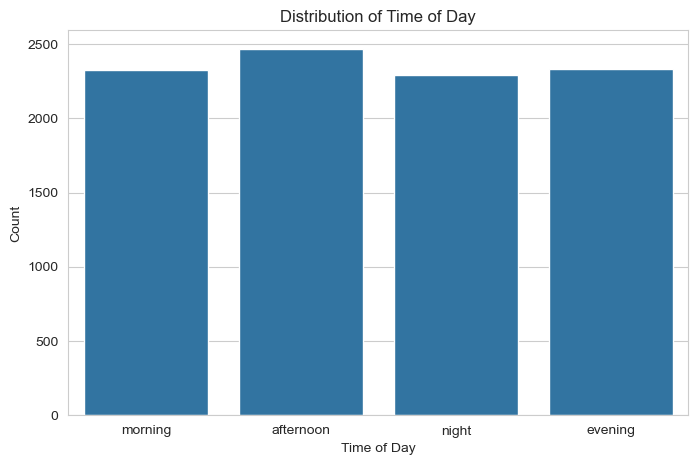

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_processed,
    x="Time of Day"
)

plt.title("Distribution of Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Count")

plt.show()

### Time of Day Observation

The dataset contains relatively balanced observations across morning, afternoon, evening, and night periods.

This balanced temporal distribution helps reduce time-based sampling bias and improves the model’s ability to learn environmental and activity patterns across different periods of the day.

In [35]:
df_processed["HVAC Operation Mode"].value_counts()

HVAC Operation Mode
maintenance_mode    1405
cooling_active      1404
heating_active      1381
off                 1374
eco_mode            1372
ventilation_only    1300
ECO_MODE             109
COOLING_ACTIVE       103
Off                   99
MAINTENANCE_MODE      99
VENTILATION_ONLY      96
HEATING_ACTIVE        94
OFF                   84
Cooling_Active        62
Eco_mode              54
Eco_Mode              51
Heating_active        50
Maintenance_mode      48
Maintenance_Mode      48
Cooling_active        48
Ventilation_Only      46
Ventilation_only      45
Heating_Active        43
Name: count, dtype: int64

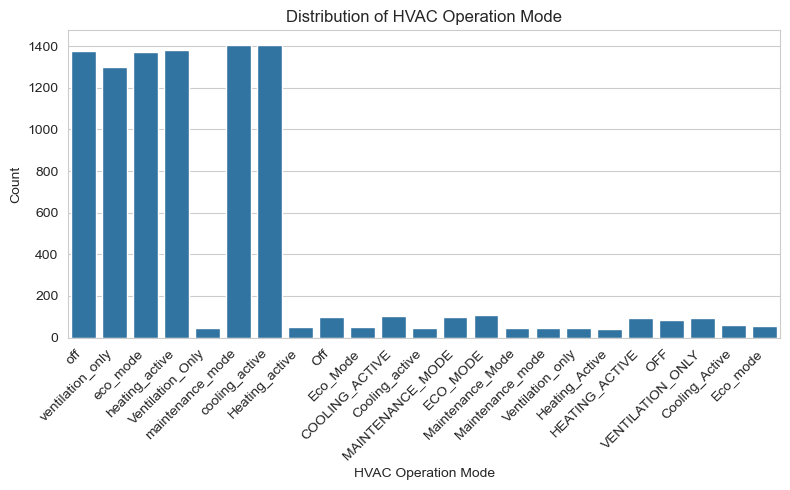

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_processed, 
    x="HVAC Operation Mode"
)

plt.title("Distribution of HVAC Operation Mode")
plt.xlabel("HVAC Operation Mode")
plt.ylabel("Count")

# Rotate the x-axis labels by 45 degrees and align them to the right
plt.xticks(rotation=45, ha="right")

# Optional: Adjusts layout so labels don't get cut off at the bottom
plt.tight_layout()

plt.show()

#### HVAC Operation Mode Observation

The HVAC operation mode feature contains several inconsistent category representations caused by:
- capitalization differences
- formatting inconsistencies
- naming variations

Examples include:
- off, Off, OFF
- cooling_active, COOLING_ACTIVE, Cooling_active

These inconsistencies may introduce unnecessary category fragmentation during feature encoding. Therefore, category standardization is required before model training.

### HVAC Operation Mode Standardization

To improve categorical consistency, HVAC operation mode labels are standardized by:
- converting text to lowercase
- removing formatting inconsistencies
- normalizing category naming

In [37]:
df_processed["HVAC Operation Mode"] = (
    df_processed["HVAC Operation Mode"]
    .str.lower()
)

In [38]:
df_processed["HVAC Operation Mode"].value_counts()

HVAC Operation Mode
cooling_active      1617
maintenance_mode    1600
eco_mode            1586
heating_active      1568
off                 1557
ventilation_only    1487
Name: count, dtype: int64

#### HVAC Operation Mode Validation Result

After standardization, inconsistent HVAC operation mode labels were successfully merged into unified categories.

The feature now contains six clean and balanced operational states:
- maintenance_mode
- cooling_active
- heating_active
- off
- eco_mode
- ventilation_only

This improves categorical consistency and reduces unnecessary feature fragmentation during machine learning preprocessing.

In [39]:
df_processed["Ambient Light Level"].value_counts()

Ambient Light Level
very_bright    4184
bright         2549
moderate       1366
dim             812
very_dim        504
Name: count, dtype: int64

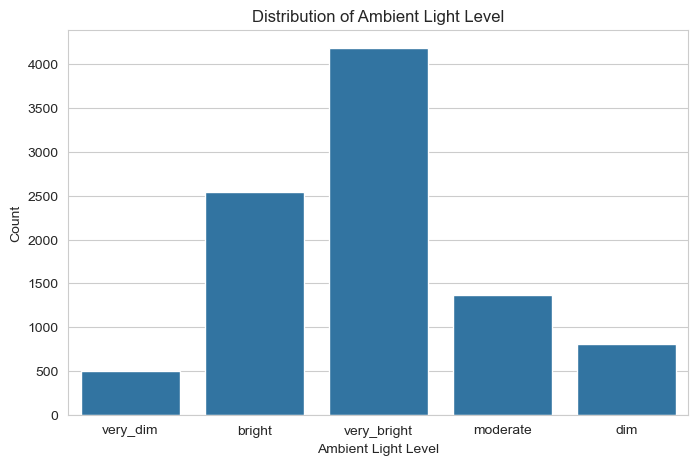

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_processed,
    x="Ambient Light Level"
)

plt.title("Distribution of Ambient Light Level")
plt.xlabel("Ambient Light Level")
plt.ylabel("Count")

plt.show()

### Ambient Light Level Observation

The ambient light level feature contains several distinct lighting conditions with relatively uneven distributions.

The most common lighting conditions are:
- very_bright
- bright

while very_dim appears less frequently.

No major category inconsistencies or formatting issues were detected in this feature.

## Target Variable Analysis

The target variable, `Activity Level`, represents the predicted activity state within the smart environment.

Analyzing its distribution helps identify potential class imbalance issues that may affect machine learning model performance.

In [41]:
df_processed["Activity Level"].value_counts()

Activity Level
Low Activity         4907
Moderate Activity    2659
High Activity        1032
ModerateActivity      317
Low_Activity          275
LowActivity           225
Name: count, dtype: int64

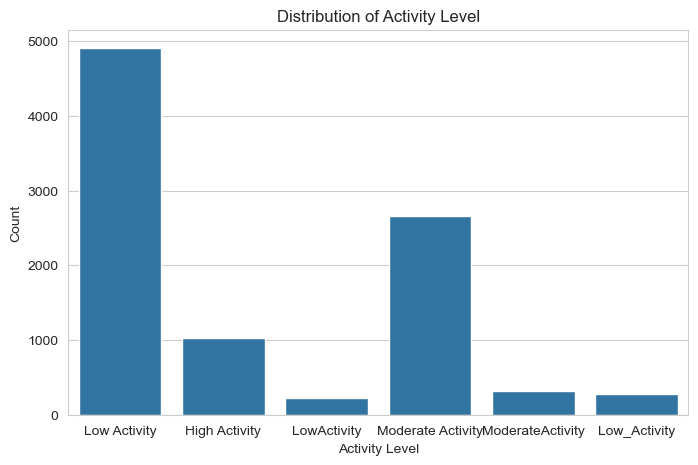

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_processed,
    x="Activity Level"
)

plt.title("Distribution of Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Count")

plt.show()

### Activity Level Observation

The activity level feature contains inconsistent category representations caused by formatting variations such as:
- spaces
- missing spaces
- underscores

Examples include:
- Low Activity, LowActivity, Low_Activity
- Moderate Activity, ModerateActivity

Since this feature is used as the target variable, category standardization is necessary to prevent label fragmentation during machine learning training and evaluation.

### Activity Level Standardization

To improve target label consistency, formatting variations are standardized into unified activity categories before machine learning preprocessing.

In [43]:
df_processed["Activity Level"] = (
    df_processed["Activity Level"]
    .replace({
        "LowActivity": "Low",
        "Low_Activity": "Low",
        "Low Activity": "Low",
        "ModerateActivity": "Moderate",
        "Moderate Activity": "Moderate",
        "High Activity": "High"
    })
)

In [44]:
df_processed["Activity Level"].value_counts()

Activity Level
Low         5407
Moderate    2976
High        1032
Name: count, dtype: int64

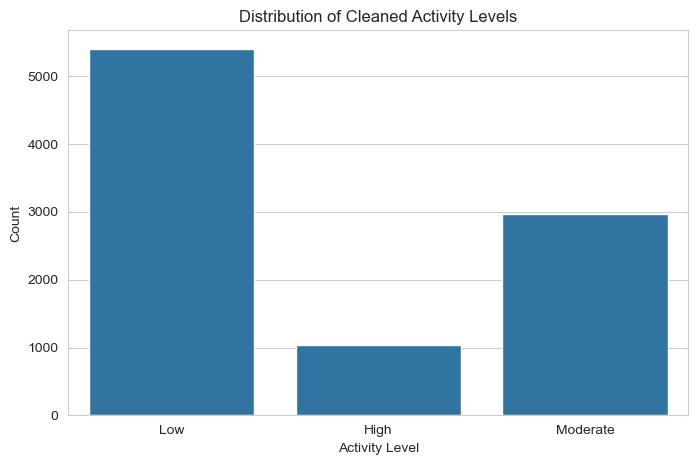

In [45]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_processed,
    x="Activity Level"
)

plt.title("Distribution of Cleaned Activity Levels")
plt.xlabel("Activity Level")
plt.ylabel("Count")

plt.show()

### Class Imbalance Observation

After standardization, the target variable contains three clean activity classes:
- Low
- Moderate
- High

The dataset shows class imbalance, with the Low activity class containing the highest number of observations while the High activity class is comparatively underrepresented.

This imbalance may affect machine learning model performance and should be considered during model training and evaluation.

# Correlation Analysis

Correlation analysis is performed to examine relationships between numerical sensor features and identify potential feature dependencies or multicollinearity.

Understanding these relationships helps support feature engineering and machine learning model development.

In [49]:
correlation_matrix = (
    df_processed[numerical_features]
    .corr()
)

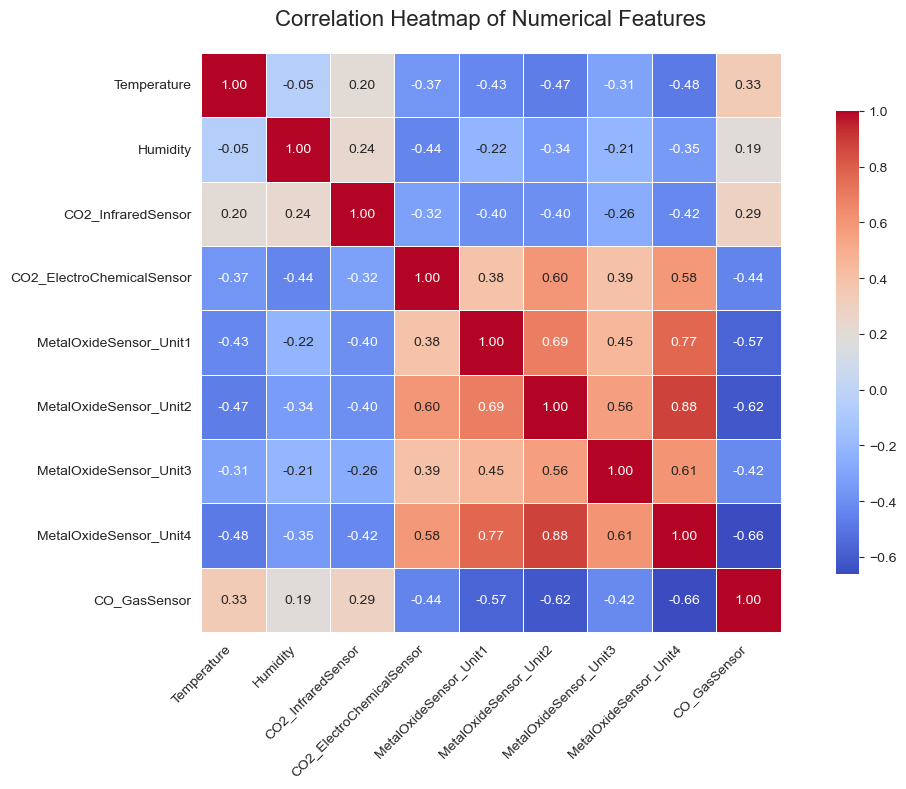

In [50]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=16,
    pad=20
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

### Correlation Analysis Observations

Several metal oxide sensor features show strong positive correlations, particularly between:
- MetalOxideSensor_Unit2 and MetalOxideSensor_Unit4
- MetalOxideSensor_Unit1 and MetalOxideSensor_Unit4

These relationships suggest that multiple metal oxide sensors may be capturing similar environmental gas patterns.

The CO_GasSensor feature shows moderate to strong negative correlations with several metal oxide sensors, indicating potentially different environmental response behaviors.

Additionally, the CO2_ElectroChemicalSensor feature demonstrates moderate positive correlations with metal oxide sensors, suggesting possible shared sensitivity to environmental gas conditions.

These findings may support future feature engineering or feature selection decisions during machine learning development.

# Feature Relationships with Activity Level

This section visualizes relationships between selected environmental sensor features and the target activity classes to identify potential separability and behavioral patterns.

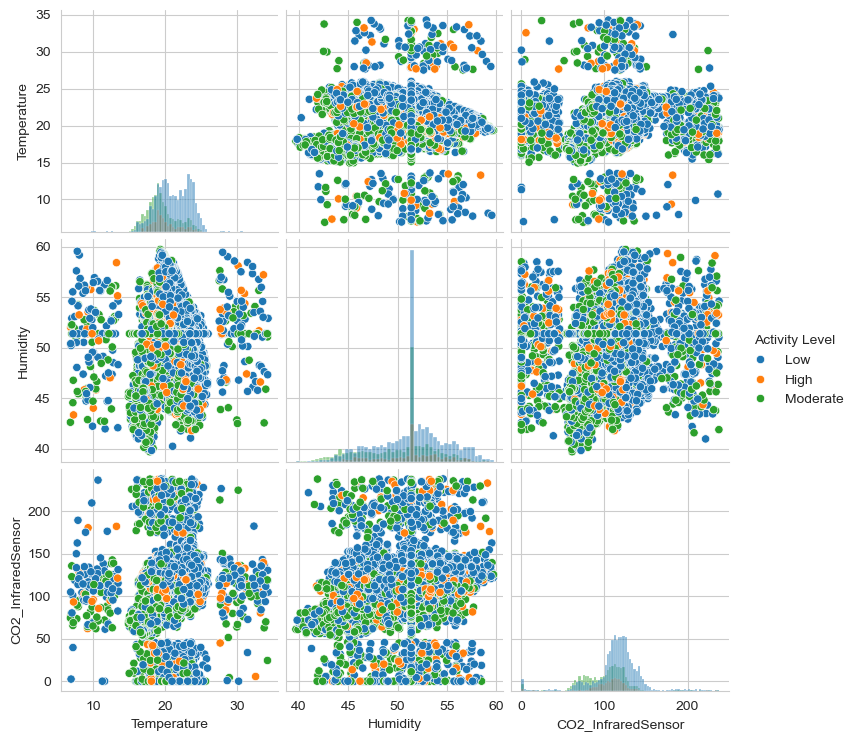

In [51]:
selected_features = [
    "Temperature",
    "Humidity",
    "CO2_InfraredSensor",
    "Activity Level"
]

sns.pairplot(
    df_processed[selected_features],
    hue="Activity Level",
    diag_kind="hist"
)

plt.show()

### Feature Relationship Observations

The pairplot visualization shows substantial overlap between the Low, Moderate, and High activity classes across temperature, humidity, and CO2 infrared sensor features.

No single feature appears capable of clearly separating activity levels independently, suggesting that machine learning models may require combined multi-feature relationships to effectively classify activity states.

Additionally, the CO2_InfraredSensor feature exhibits wider variability and more complex distribution patterns compared to temperature and humidity, indicating potentially stronger environmental sensitivity.

# Dataset Cleaning Summary

The dataset was progressively cleaned and validated throughout the exploratory data analysis process to improve data consistency and reliability before machine learning development.

In [53]:
cleaning_summary = pd.DataFrame({
    "Stage": [
        "Original Dataset",
        "After Duplicate Removal",
        "Final Processed Dataset"
    ],
    "Rows": [
        len(df),
        len(df.drop_duplicates()),
        len(df_processed)
    ],
    "Columns": [
        df.shape[1],
        df.shape[1],
        df_processed.shape[1]
    ]
})

cleaning_summary

,Stage,Rows,Columns
0,Original Dataset,10000,14
1,After Duplicate Removal,9829,14
2,Final Processed Dataset,9415,14


# EDA Conclusion

The exploratory data analysis process successfully identified and addressed multiple data quality and consistency issues within the environmental monitoring dataset.

Major preprocessing and validation findings included:
- missing values in multiple sensor features
- duplicate observations
- inconsistent categorical labels
- invalid humidity measurements
- potential temperature anomalies
- class imbalance within the target variable
- strong correlations among metal oxide sensor features

After preprocessing and validation, the dataset became significantly cleaner and more suitable for machine learning development.

The analysis also revealed that activity classification is unlikely to depend on a single environmental feature alone, suggesting that machine learning models will require combined multi-feature relationships for effective prediction performance.

# Processed Dataset Export

The final cleaned and validated dataset was exported to the processed data directory for downstream machine learning development, feature engineering, and model training tasks.

In [54]:
df_processed.to_csv(
    "../data/processed/gas_monitoring_processed.csv",
    index=False
)

In [56]:
df_processed.shape

(9415, 14)

In [55]:
df_processed.head()

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low
1,morning,19.66,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,very_bright,Low
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,1.0,7241,eco_mode,very_bright,High
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,Low
